<a href="https://colab.research.google.com/github/simon-mellergaard/GAI-with-LLMs/blob/main/Project%20codes/Assignment06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6

> *With point of departure in the Optimizing RAG notebook improve on the baseline performance of the RAG pipeline. Report accuracy and latency for three selected experiments and reflect on your results.*

## Setup

In [ ]:
# Install packages
!pip install -q pypdf langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [67]:
# Libraries
import torch
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Functions
from huggingface_hub import hf_hub_download
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer, util, CrossEncoder
from transformers import pipeline

In [4]:
# Setting up the device
device = "cuda" if torch.cuda.is_available() else "cpu"

## Importing helper functions

In [5]:
def download_documents(document_name="GoldmanSachs", cache_dir="./haystack_data"):
    """
    Download PDFs and metadata from the Document Haystack dataset.

    Args:
        document_name: Name of document to download (e.g., "GoldmanSachs", "AIG", "AmericanAirlines")
                      Or "all" to download all available documents
        cache_dir: Local directory to store downloaded files

    Returns:
        Path to the base directory containing downloaded documents
    """
    # Available documents in the dataset
    all_documents = [
        "GoldmanSachs", "AIG", "AmericanAirlines", "APA", "BankOfMontreal",
        "BristolMyers", "CVS", "Chevron", "Cigna", "Chubb", "Comcast",
        "ConocoPhillips", "Disney", "ExxonMobil", "FedEx", "Ford",
        "GeneralMotors", "HCA", "JPMorgan", "JohnsonJohnson", "Lowes",
        "MetLife", "Progressive", "Tesla", "UnitedHealth"
    ]

    if document_name == "all":
        documents_to_download = all_documents
    else:
        if document_name not in all_documents:
            print(f"Warning: {document_name} not in known documents. Attempting anyway...")
        documents_to_download = [document_name]

    page_lengths = [5, 10, 25, 50, 75, 100, 150, 200]
    base_path = Path(cache_dir)
    base_path.mkdir(exist_ok=True)

    print(f"Downloading documents: {', '.join(documents_to_download)}")
    print("="*70)

    for doc_name in documents_to_download:
        print(f"\n📄 Downloading {doc_name}...")

        for pages in page_lengths:
            folder_name = f"{doc_name}_{pages}Pages"

            try:
                # Download PDF with text needles
                hf_hub_download(
                    repo_id="AmazonScience/document-haystack",
                    repo_type="dataset",
                    filename=f"{doc_name}/{folder_name}/{doc_name}_{pages}Pages_TextNeedles.pdf",
                    local_dir=str(base_path),
                    local_dir_use_symlinks=False
                )

                # Download needles.csv
                hf_hub_download(
                    repo_id="AmazonScience/document-haystack",
                    repo_type="dataset",
                    filename=f"{doc_name}/{folder_name}/needles.csv",
                    local_dir=str(base_path),
                    local_dir_use_symlinks=False
                )

                # Download prompt_questions.txt
                hf_hub_download(
                    repo_id="AmazonScience/document-haystack",
                    repo_type="dataset",
                    filename=f"{doc_name}/{folder_name}/prompt_questions.txt",
                    local_dir=str(base_path),
                    local_dir_use_symlinks=False
                )

            except Exception as e:
                print(f"   ✗ Error downloading {pages}-page document: {e}")

        print(f"   ✓ {doc_name} downloaded")

    return base_path

In [6]:
def load_test_cases(base_path, document_name="GoldmanSachs"):
    """
    Load test cases from downloaded documents.
    """
    test_cases = []
    page_lengths = [5, 10, 25, 50, 75, 100, 150, 200]

    print(f"Looking for documents in: {base_path}")

    # The files are in base_path/DocumentName/DocumentName_XPages/

    doc_base = base_path / document_name

    if not doc_base.exists():
        print(f"ERROR: Document folder not found at {doc_base}")
        print(f"Available folders: {list(base_path.iterdir())}")
        return test_cases

    print(f"\nProcessing {document_name}...")

    for pages in page_lengths:
        folder_name = f"{document_name}_{pages}Pages"
        folder_path = doc_base / folder_name

        if not folder_path.exists():
            continue

        pdf_path = folder_path / f"{document_name}_{pages}Pages_TextNeedles.pdf"
        needles_csv_path = folder_path / "needles.csv"
        prompts_path = folder_path / "prompt_questions.txt"

        if not pdf_path.exists() or not needles_csv_path.exists():
            print(f"  ✗ Missing files in {folder_path}")
            continue

        print(f"  ✓ Loading {pages}-page document...")

        # Load PDF
        loader = PyPDFLoader(str(pdf_path))
        docs = loader.load()
        full_document = "\n\n".join([doc.page_content for doc in docs])

        # Read needles and prompts
        needles_df = pd.read_csv(needles_csv_path, header=None, names=["needle_text"])
        with open(prompts_path, 'r') as f:
            prompts = [line.strip() for line in f.readlines() if line.strip()]

        # Extract expected answers
        for idx, needle in enumerate(needles_df["needle_text"]):
            match = re.search(r'The secret (.+?) is ["\']?(.+?)["\']?\.?$', needle)
            if match and idx < len(prompts):
                key = match.group(1)
                value = match.group(2).strip('."\'')

                test_cases.append({
                    "document_name": document_name,
                    "document_length": pages,
                    "needle": needle,
                    "key": key,
                    "expected_value": value,
                    "prompt": prompts[idx],
                    "full_document": full_document
                })

        print(f"    Added {len(needles_df)} test cases")

    print(f"\n✓ Total test cases loaded: {len(test_cases)}")
    return test_cases

### RAG components

In [7]:
class Chunker:
    """Handles document chunking - easily swappable"""

    def __init__(self, chunk_size=500, chunk_overlap=100):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap
        )

    def chunk(self, document_text):
        """Split document into chunks"""
        return self.splitter.split_text(document_text)

In [8]:
class Embedder:
    """Handles embedding - easily swappable"""

    def __init__(self, model_name="BAAI/bge-small-en-v1.5"):
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)

    def embed(self, texts):
        """Embed texts into vectors"""
        return self.model.encode(texts, convert_to_tensor=True)

In [9]:
class Retriever:
    """Handles retrieval - easily swappable"""

    def __init__(self, embedder):
        self.embedder = embedder

    def retrieve(self, query, chunks, chunk_embeddings, top_k=5):
        """Retrieve top-k most relevant chunks"""
        query_embedding = self.embedder.embed(query)
        similarities = util.pytorch_cos_sim(query_embedding, chunk_embeddings)

        # Handle case where top_k is larger than number of chunks
        actual_k = min(top_k, len(chunks))
        top_k_indices = similarities[0].topk(actual_k).indices
        return [chunks[i] for i in top_k_indices]

In [10]:
class Reranker:
    """Handles reranking of retrieved chunks - optional component"""

    def __init__(self, model_name='cross-encoder/ms-marco-MiniLM-L-6-v2'):
        """
        Initialize reranker with a cross-encoder model.

        Args:
            model_name: HuggingFace model name for cross-encoder
                       Popular options:
                       - 'cross-encoder/ms-marco-MiniLM-L-6-v2' (fast, good)
                       - 'BAAI/bge-reranker-base' (high quality, decent size)
        """
        self.model_name = model_name
        self.model = CrossEncoder(model_name)

    def rerank(self, query, chunks, top_k=None):
        """
        Rerank chunks based on query-chunk relevance scores.

        Args:
            query: Search query
            chunks: List of text chunks to rerank
            top_k: Return only top_k after reranking (None = return all)

        Returns:
            List of reranked chunks
        """
        # Create pairs of [query, chunk] for cross-encoder
        pairs = [[query, chunk] for chunk in chunks]

        # Get relevance scores
        scores = self.model.predict(pairs)

        # Sort chunks by score (descending)
        ranked_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
        reranked_chunks = [chunks[i] for i in ranked_indices]

        # Return top_k if specified
        if top_k:
            return reranked_chunks[:top_k]
        return reranked_chunks

In [11]:
class Generator:
    """Handles answer generation - easily swappable"""

    def __init__(self, model_name="HuggingFaceTB/SmolLM-135M-Instruct"):
        device = 0 if torch.cuda.is_available() else -1
        self.pipeline = pipeline(
            "text-generation",
            model=model_name,
            device=device
        )
        self.system_prompt = (
            "You are a helpful assistant that answers questions based on the given context. "
            "Provide direct, concise answers."
        )

    def generate(self, query, context_chunks):
        """Generate answer from query and context"""
        context = "\n".join(context_chunks)
        prompt = f"Context:\n{context}\n\nQuestion: {query}\nAnswer:"

        messages = [
            {"role": "system", "content": self.system_prompt},
            {"role": "user", "content": prompt},
        ]

        response = self.pipeline(messages, max_new_tokens=100)
        return response[0]["generated_text"][-1]["content"]

In [12]:
class RAGPipeline:
    """Complete RAG pipeline - compose all components"""

    def __init__(self, chunker, embedder, retriever, generator, reranker=None):
        """
        Initialize RAG pipeline.

        Args:
            chunker: Chunker instance
            embedder: Embedder instance
            retriever: Retriever instance
            generator: Generator instance
            reranker: Optional Reranker instance (None = no reranking)
        """
        self.chunker = chunker
        self.embedder = embedder
        self.retriever = retriever
        self.generator = generator
        self.reranker = reranker

    def prepare_document(self, document_text):
        """Prepare document for retrieval"""
        chunks = self.chunker.chunk(document_text)
        embeddings = self.embedder.embed(chunks)
        return chunks, embeddings

    def query(self, query, chunks, chunk_embeddings, top_k=5, rerank_top_k=None):
        """
        Run full RAG pipeline with optional reranking.

        Args:
            query: User query
            chunks: Document chunks
            chunk_embeddings: Pre-computed embeddings
            top_k: Number of chunks to retrieve initially
            rerank_top_k: If reranker is used, return this many after reranking
                         (None = return same as top_k)

        Returns:
            (answer, context_chunks) tuple
        """
        # Step 1: Initial retrieval with embeddings
        if self.reranker:
            # Retrieve more candidates for reranking, but not more than available chunks
            initial_k = min(top_k * 3, len(chunks))
            context_chunks = self.retriever.retrieve(query, chunks, chunk_embeddings, initial_k)

            # Step 2: Rerank the candidates
            final_k = rerank_top_k if rerank_top_k else top_k
            context_chunks = self.reranker.rerank(query, context_chunks, top_k=final_k)
        else:
            # No reranking - just retrieve
            context_chunks = self.retriever.retrieve(query, chunks, chunk_embeddings, top_k)

        # Step 3: Generate answer
        answer = self.generator.generate(query, context_chunks)

        return answer, context_chunks

### Evaluation

In [13]:
def evaluate_rag(test_cases, rag_pipeline, top_k=5, verbose=False, use_llm=True):
    """
    Evaluate RAG pipeline on needle-in-haystack test cases.

    Args:
        test_cases: List of test case dictionaries
        rag_pipeline: RAGPipeline instance to evaluate
        top_k: Number of chunks to retrieve
        verbose: If True, print detailed progress
        use_llm: If True, use LLM to generate answer. If False, just check if needle is in retrieved chunks.

    Returns:
        Dictionary with evaluation results
    """
    if not test_cases:
        print("ERROR: No test cases provided!")
        return {"accuracy": 0, "correct": 0, "total": 0, "time": 0, "results": []}

    results = []
    correct = 0
    total = len(test_cases)

    # Group by document for efficiency
    by_document = {}
    for case in test_cases:
        doc_key = (case["document_name"], case["document_length"])
        if doc_key not in by_document:
            by_document[doc_key] = []
        by_document[doc_key].append(case)

    start_time = time.time()

    if verbose:
        mode = "with LLM generation" if use_llm else "retrieval-only (no LLM)"
        print(f"Evaluating {total} test cases ({mode})...")
        print("="*70)

    for doc_key in sorted(by_document.keys()):
        cases = by_document[doc_key]
        doc_name, doc_length = doc_key

        if verbose:
            print(f"\n📄 {doc_name} - {doc_length} pages ({len(cases)} needles)")

        # Prepare document once
        first_case = cases[0]
        chunks, embeddings = rag_pipeline.prepare_document(first_case["full_document"])

        if verbose:
            print(f"   Chunked into {len(chunks)} chunks")

        # Test each needle
        for i, case in enumerate(cases, 1):
            expected_clean = case["expected_value"].lower().strip()
            expected_clean = expected_clean.replace('a "', '').replace('an "', '').replace('the "', '').replace('"', '').strip()

            if use_llm:
                # Use full RAG pipeline with LLM generation
                answer, context_chunks = rag_pipeline.query(
                    case["prompt"],
                    chunks,
                    embeddings,
                    top_k=top_k
                )

                # Check if expected value is in the generated answer
                answer_lower = answer.lower()
                found = expected_clean in answer_lower

            else:
                # Retrieval-only mode: just check if needle is in retrieved chunks
                if rag_pipeline.reranker:
                    # With reranker: retrieve more, then rerank
                    initial_k = min(top_k * 3, len(chunks))
                    context_chunks = rag_pipeline.retriever.retrieve(
                        case["prompt"],
                        chunks,
                        embeddings,
                        initial_k
                    )
                    context_chunks = rag_pipeline.reranker.rerank(
                        case["prompt"],
                        context_chunks,
                        top_k=top_k
                    )
                else:
                    # No reranker: just retrieve
                    context_chunks = rag_pipeline.retriever.retrieve(
                        case["prompt"],
                        chunks,
                        embeddings,
                        top_k=top_k
                    )

                # Check if expected value is in retrieved chunks
                retrieved_text = " ".join(context_chunks).lower()
                found = expected_clean in retrieved_text

                answer = "[Retrieval-only mode - no answer generated]"

            if found:
                correct += 1

            results.append({
                "document_name": doc_name,
                "document_length": doc_length,
                "prompt": case["prompt"],
                "expected": expected_clean,
                "answer": answer,
                "found": found
            })

            if verbose:
                status = "✓" if found else "✗"
                print(f"   [{i}/{len(cases)}] {status} {case['key']}: expected '{expected_clean}'")

    total_time = time.time() - start_time
    accuracy = (correct / total) * 100 if total > 0 else 0

    # Print summary
    print("\n" + "="*70)
    print("RESULTS")
    print("="*70)
    mode_str = "(with LLM)" if use_llm else "(retrieval-only)"
    print(f"Mode: {mode_str}")
    print(f"Accuracy: {accuracy:.2f}% ({correct}/{total} correct)")
    print(f"Time: {total_time:.2f}s ({total_time/total*1000:.0f}ms per query)" if total > 0 else "Time: 0.00s")
    print("="*70)

    return {
        "accuracy": accuracy,
        "correct": correct,
        "total": total,
        "time": total_time,
        "use_llm": use_llm,
        "results": results
    }


## Experiments

Time to do some experimienting! First, the dataset is loaded. This is done from the [Haystack documents](https://huggingface.co/datasets/AmazonScience/document-haystack).

In [17]:
# Download data (could also be "AIG", "Tesla", "all", etc.)
base_path = download_documents("GoldmanSachs")

# Load test cases
test_cases = load_test_cases(base_path, "GoldmanSachs")


📄 Downloading GoldmanSachs...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


   ✓ GoldmanSachs downloaded
Looking for documents in: haystack_data

Processing GoldmanSachs...
  ✓ Loading 5-page document...
    Added 5 test cases
  ✓ Loading 10-page document...
    Added 10 test cases
  ✓ Loading 25-page document...
    Added 25 test cases
  ✓ Loading 50-page document...
    Added 25 test cases
  ✓ Loading 75-page document...
    Added 25 test cases
  ✓ Loading 100-page document...
    Added 25 test cases
  ✓ Loading 150-page document...
    Added 25 test cases
  ✓ Loading 200-page document...
    Added 25 test cases

✓ Total test cases loaded: 165


### Establishing the baseline

The baseline is defined with the following RAG-parameter, and will be improved.

In [44]:
chunker = Chunker(chunk_size=500, chunk_overlap=100)
embedder = Embedder(model_name="BAAI/bge-small-en-v1.5")
retriever = Retriever(embedder)
generator = Generator(model_name="HuggingFaceTB/SmolLM-135M-Instruct")
pipe = RAGPipeline(chunker, embedder, retriever, generator)

Device set to use cuda:0


In [45]:
results_base_retrieval = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=False)


RESULTS
Mode: (retrieval-only)
Accuracy: 85.45% (141/165 correct)
Time: 18.17s (110ms per query)


In [46]:
results_base= evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=True)


RESULTS
Mode: (with LLM)
Accuracy: 24.85% (41/165 correct)
Time: 563.01s (3412ms per query)


The baseline only achieves a

### Experiment 1

To improve on the baseline, the first step would be to find better modelsfor the RAG pipeline. This includes the generator, the embedder and the reranker. The following websites have been used for finding good models for these tasks:

* [LLM models](https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard#/)
* [Embedders and rerankers](https://huggingface.co/spaces/mteb/leaderboard)

When chosing models, there will be a trade-off between performance and model-size/run-time. Here the Colab hardware is also a bottleneck in terms of the weight of the models.

**Models used in experiment**:
* Embedder: [bge-base-en-v1.5](https://huggingface.co/BAAI/bge-base-en-v1.5)
* Generator: [SmolLM2-360M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-360M-Instruct)
* Reranker: [bge-reranker-base](https://huggingface.co/BAAI/bge-reranker-base)

The embedder and generator models are direct upgrades from the baseline, with a newer and larger version of SmolLM, and a larger version of bge. Additionally, a reranker has been added. This should improve performance.

In [127]:
def generate_example(pipe):
    """Generates a single RAG example given a pipeline"""
    sample_case = [case for case in test_cases if case["document_length"] == 10][0]
    document_text = sample_case["full_document"]
    chunks, embeddings = pipe.prepare_document(document_text)

    print(f"Document prepared: {len(chunks)} chunks created")
    print(f"Testing query: {sample_case['prompt']}")
    print(f"Expected answer: {sample_case['expected_value']}\n")

    # Query
    answer, context = pipe.query(sample_case["prompt"], chunks, embeddings, top_k=5)
    print(context[0][:200] + "...")

In [126]:
# Defining the pipeline
chunker = Chunker(chunk_size=500, chunk_overlap=100)
embedder = Embedder(model_name="BAAI/bge-base-en-v1.5")
retriever = Retriever(embedder)
generator = Generator(model_name="HuggingFaceTB/SmolLM2-360M-Instruct")
reranker = Reranker(model_name='BAAI/bge-reranker-base')
pipe = RAGPipeline(chunker, embedder, retriever, generator, reranker)

generate_example(pipe)

Device set to use cuda:0


Document prepared: 25 chunks created
Testing query: What is the secret flower in the document?
Expected answer: lavender

Annual Report
2023
THE GOLDMAN SACHS GROUP , INC.
The secret flower is "lavender".

The secret tool is "scissors"....


The sample query seems to give a reasonable answer, despite also including the secret tool, which is not asked for. Time to evaluate on the entire set.

In [64]:
results_ex1_retrieval = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=False)


RESULTS
Mode: (retrieval-only)
Accuracy: 92.12% (152/165 correct)
Time: 71.77s (435ms per query)


In [69]:
results_ex1 = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=True)


RESULTS
Mode: (with LLM)
Accuracy: 81.82% (135/165 correct)
Time: 225.50s (1367ms per query)


A solid improvement against the baseline, both in terms of retrieval and RAG, however there is still room for improvement. In order to further inspect the performance, a plot of the document length and the missed needles can be created as a stacked bar graph:

In [117]:
def plot_results(results, results_retrieval):
    # Process the results to count incorrect predictions per document length
    incorrect_counts = {}
    for result in results["results"]:
        if not result["found"]:
            doc_length = result["document_length"]
            if doc_length not in incorrect_counts:
                incorrect_counts[doc_length] = 0
            incorrect_counts[doc_length] += 1

    incorrect_counts_retrieval = {}
    for result in results_retrieval["results"]:
        if not result["found"]:
            doc_length = result["document_length"]
            if doc_length not in incorrect_counts_retrieval:
                incorrect_counts_retrieval[doc_length] = 0
            incorrect_counts_retrieval[doc_length] += 1

    # Sort the document lengths for plotting
    sorted_doc_lengths = sorted(incorrect_counts.keys())
    incorrect_counts_sorted = [incorrect_counts[length] for length in sorted_doc_lengths]
    # Sort the document lengths for plotting
    sorted_doc_retrieval_lengths = sorted(incorrect_counts_retrieval.keys())
    incorrect_counts_retrieval_sorted = [incorrect_counts_retrieval[length] for length in sorted_doc_retrieval_lengths]

    plt.figure(figsize=(6, 4))
    # Plot the total mislabeled classes (RAG)
    sns.set_color_codes("pastel")
    sns.barplot(x=sorted_doc_lengths, y=incorrect_counts_sorted,
                label="Total", color="b")

    # Plot the retrieval misses
    sns.set_color_codes("muted")
    sns.barplot(x=sorted_doc_retrieval_lengths, y=incorrect_counts_retrieval_sorted,
            label="Retrieval", color="b")
    plt.show()

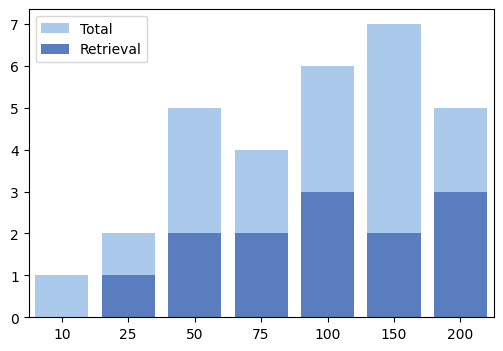

In [114]:
plot_results(results_ex1, results_ex1_retrieval)

The stacked bar graph can be created, as all the missed retrievals should also be missed in the RAG, as the generator should have no idea what the secret is if it is not provided as the context, unless it has an extremely lucky guess.

Looking at the graph, there seems to be a lot of mistakes in the longer documents, both from the retriever and the RAG itself. The generator also seems to have some problems finding the correct generations, as there are still a lot of cases where the correct context is provided, but the answer is wrong.

### Experiment 2

This experiment adjusts the chunker to have smaller chunks with a bigger overlap. This should increase the latency, but add more context to the model, as there is a bigger overlap.

**Models used in experiment**:

* Embedder: [bge-base-en-v1.5](https://huggingface.co/BAAI/bge-base-en-v1.5)
* Generator: [SmolLM2-360M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-360M-Instruct)
* Reranker: [bge-reranker-base](https://huggingface.co/BAAI/bge-reranker-base)

In [70]:
# Defining the pipeline
chunker = Chunker(chunk_size=400, chunk_overlap=200) # Smaller chunks
embedder = Embedder(model_name="BAAI/bge-base-en-v1.5")
retriever = Retriever(embedder)
generator = Generator(model_name="HuggingFaceTB/SmolLM2-360M-Instruct")
reranker = Reranker(model_name='BAAI/bge-reranker-base')
pipe = RAGPipeline(chunker, embedder, retriever, generator, reranker)

generate_example(pipe)

Device set to use cuda:0


Testing query: What is the secret flower in the document?
Expected answer: lavender
Annual Report
2023
THE GOLDMAN SACHS GROUP , INC.
The secret flower is "lavender".

The secret tool is "scissors"....


In [71]:
results_ex2_retrieval = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=False)


RESULTS
Mode: (retrieval-only)
Accuracy: 94.55% (156/165 correct)
Time: 102.56s (622ms per query)


In [76]:
results_ex2 = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=True)


RESULTS
Mode: (with LLM)
Accuracy: 89.09% (147/165 correct)
Time: 234.77s (1423ms per query)


This experiment improves the accuracy to 89%. The results can be plotted:

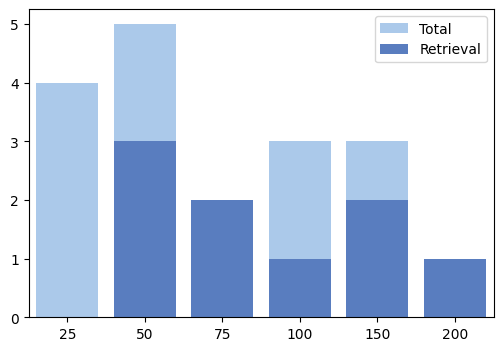

In [122]:
plot_results(results_ex2, results_ex2_retrieval)

This is a pretty good result, with an improvement above the previous experiment. There is surprisingly many mistakes in the 25-page document from the generator itself (correct retrieval). This seem to advocate for a better generator model, as this might improve the performance.

### Experiment 3

The top-k retrieved documents have been increased from 5 to 10.

**Models used in experiment**:
* Embedder: [bge-base-en-v1.5](https://huggingface.co/BAAI/bge-base-en-v1.5)
* Generator: [SmolLM2-360M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-360M-Instruct)
* Reranker: [bge-reranker-base](https://huggingface.co/BAAI/bge-reranker-base)

In [78]:
# Defining the pipeline
chunker = Chunker(chunk_size=400, chunk_overlap=200) # Smaller chunks
embedder = Embedder(model_name="BAAI/bge-base-en-v1.5")
retriever = Retriever(embedder)
generator = Generator(model_name="HuggingFaceTB/SmolLM2-360M-Instruct")
reranker = Reranker(model_name='BAAI/bge-reranker-base')
pipe = RAGPipeline(chunker, embedder, retriever, generator, reranker)

generate_example(pipe)

Device set to use cuda:0


Testing query: What is the secret flower in the document?
Expected answer: lavender
Annual Report
2023
THE GOLDMAN SACHS GROUP , INC.
The secret flower is "lavender".

The secret tool is "scissors"....


In [37]:
results_ex3_retrieval = evaluate_rag(test_cases, pipe, top_k=10, verbose=True, use_llm=False)

Evaluating 165 test cases (retrieval-only (no LLM))...

📄 GoldmanSachs - 5 pages (5 needles)
   Chunked into 18 chunks
   [1/5] ✓ flower: expected 'lavender'
   [2/5] ✓ tool: expected 'scissors'
   [3/5] ✓ shape: expected 'star'
   [4/5] ✓ clothing: expected 'dress'
   [5/5] ✓ office supply: expected 'envelope'

📄 GoldmanSachs - 10 pages (10 needles)
   Chunked into 43 chunks
   [1/10] ✓ flower: expected 'lavender'
   [2/10] ✓ tool: expected 'scissors'
   [3/10] ✓ shape: expected 'star'
   [4/10] ✓ clothing: expected 'dress'
   [5/10] ✓ office supply: expected 'envelope'
   [6/10] ✓ fruit: expected 'grape'
   [7/10] ✓ drink: expected 'milk'
   [8/10] ✓ transportation: expected 'airplane'
   [9/10] ✓ landmark: expected 'colosseum'
   [10/10] ✓ kitchen appliance: expected 'toaster'

📄 GoldmanSachs - 25 pages (25 needles)
   Chunked into 228 chunks
   [1/25] ✓ flower: expected 'lavender'
   [2/25] ✓ tool: expected 'scissors'
   [3/25] ✓ shape: expected 'star'
   [4/25] ✓ clothing: expecte

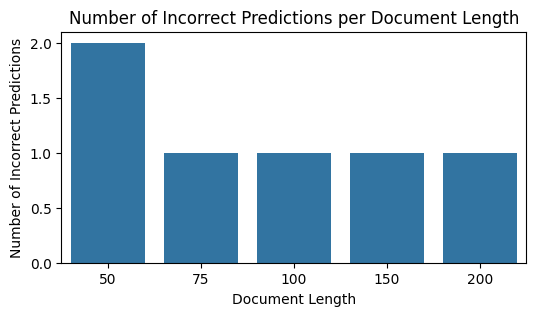

In [38]:
plot_results(results_ex3_retrieval)

In [39]:
results_ex3 = evaluate_rag(test_cases, pipe, top_k=10, verbose=True, use_llm=True)

Evaluating 165 test cases (with LLM generation)...

📄 GoldmanSachs - 5 pages (5 needles)
   Chunked into 18 chunks
   [1/5] ✓ flower: expected 'lavender'
   [2/5] ✓ tool: expected 'scissors'
   [3/5] ✓ shape: expected 'star'
   [4/5] ✓ clothing: expected 'dress'
   [5/5] ✓ office supply: expected 'envelope'

📄 GoldmanSachs - 10 pages (10 needles)
   Chunked into 43 chunks
   [1/10] ✓ flower: expected 'lavender'
   [2/10] ✓ tool: expected 'scissors'
   [3/10] ✓ shape: expected 'star'
   [4/10] ✓ clothing: expected 'dress'
   [5/10] ✓ office supply: expected 'envelope'
   [6/10] ✓ fruit: expected 'grape'
   [7/10] ✓ drink: expected 'milk'
   [8/10] ✓ transportation: expected 'airplane'
   [9/10] ✓ landmark: expected 'colosseum'
   [10/10] ✓ kitchen appliance: expected 'toaster'

📄 GoldmanSachs - 25 pages (25 needles)
   Chunked into 228 chunks
   [1/25] ✓ flower: expected 'lavender'
   [2/25] ✓ tool: expected 'scissors'
   [3/25] ✓ shape: expected 'star'
   [4/25] ✓ clothing: expected 'd

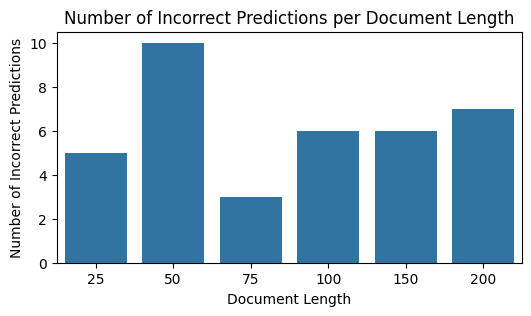

In [40]:
plot_results(results_ex3)

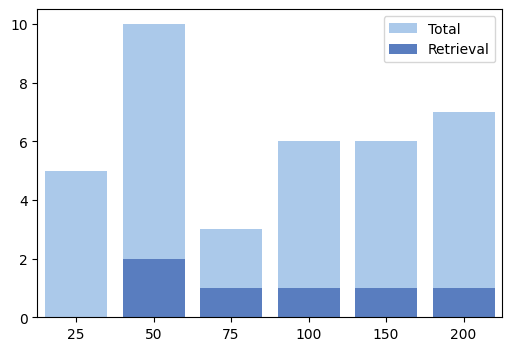

In [116]:
plot_results_advanced(results_ex3, results_ex3_retrieval)

## Results and reflection

The results of the three experiments can be seen in the table below

In [124]:
results_retrival = {
    'Baseline': results_base_retrieval,
    'Experiment 1': results_ex1_retrieval,
    'Experiment 2': results_ex2_retrieval,
    'Experiment 3': results_ex3_retrieval
}

# Convert to dataframe
results_table_retrival = pd.DataFrame(results_retrival).transpose()[['accuracy', 'time']]
results_table_retrival.columns = ['Retriever Accuracy (%)', 'Retriever Latency (s)']

results = {
    'Baseline': results_base,
    'Experiment 1': results_ex1,
    'Experiment 2': results_ex2,
    'Experiment 3': results_ex3
}

# Convert to dataframe
results_table = pd.DataFrame(results).transpose()[['accuracy', 'time']]
results_table.columns = ['RAG Accuracy (%)', 'RAG Latency (s)']

# Joining tables
results_table = results_table_retrival.join(results_table)
display(results_table.style.format("{:.3f}"))

,Retriever Accuracy (%),Retriever Latency (s),RAG Accuracy (%),RAG Latency (s)
Baseline,85.455,18.171,24.848,563.010
Experiment 1,92.121,71.765,81.818,225.502
Experiment 2,94.545,102.564,89.091,234.773
Experiment 3,96.364,119.187,77.576,306.378


The results show that